<a href="https://colab.research.google.com/github/Miladatasys/DIP-AI/blob/Curso2/primer_trabajo_mila.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preparacion de Entorno**

In [ ]:
# Importacion de librerias

import numpy as np  # Calculos matematicos, arreglos y matrices.
import pandas as pd # Trabajar con datos tabulares tipo csv o bd para estructuras como dataframes
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor # Modelos de ml
from sklearn.tree import DecisionTreeRegressor  # Relacion entre variables con una linea recta
from sklearn.model_selection import train_test_split  # Division del dataset en dos partes, una de entrenamiento y otra de prueba para evaluar el modelo
from sklearn.impute import KNNImputer # Rellenar valores faltantes del data set utilizando la tecnica knn
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error # Medir que tambien funciona mi modelo. promedio de los errores al cuadrado, la viabilidad entre 0 y 1, promedio del valor absoluto, promedio del error absoluto
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures  # Transformar y preparar los datos antes de entrenar el modelo, estandariza los datos para que tengan media 0 y desviacion estandar 1, escala los datos al rango definido, como 0 y 1, genera caracteristicas polinomicas para capturar relaciones no lineales
import matplotlib.pyplot as plt # Crear graficos como de lineas, barras, dispersion
import seaborn as sns # Basada en matplot, tiene estilos mas bonitos para graficos estadisticos


# **Set de Datos**

In [ ]:
# Cargar del archivo csv

df  = pd.read_csv('historia_climatica.csv')

# Inspeccionar la primera fila del dataset
df.head()


# print("Primeras 5 filas del dataset: ")
# print(df.head())

,Summary,Precip Type,Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Fecha
0,Partly Cloudy,rain,9.472222,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-04-01 00:00:00
1,Partly Cloudy,rain,9.355556,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-04-01 01:00:00
2,Mostly Cloudy,rain,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 02:00:00
3,Partly Cloudy,rain,8.288889,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 03:00:00
4,Mostly Cloudy,rain,8.755556,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 04:00:00


# **Parte 1 - Exploracion de los datos**

Paso 1.1: Inspeccionar valores faltantes


In [ ]:
print("Valores faltantes por columna: ")
print(df.isnull().sum())

# En Precip Type faltan 1472 datos, en Wind Speed 2101 y en Pressure 172

Valores faltantes por columna: 
Summary                      0
Precip Type               1472
Temperature (C)              0
Humidity                     0
Wind Speed (km/h)         2101
Wind Bearing (degrees)       0
Visibility (km)              0
Loud Cover                   0
Pressure (millibars)       172
Daily Summary                0
Fecha                        0
dtype: int64



Paso 1.2: Encontrar estrategia mas adecuada para tratar valores nulos para cada una de las 3 columnas

Porcentaje de valores nulos en comparacion con el total de filas, cuanto menor sea el porcentaje de valores faltantes, mas sencillo sera imputarlos sin afectar tanto la integridad del dataset



```
Proporcion de datos faltantes (%) = numero de valores faltantes/ numero total de filas * 100
```



Analisis columna **Precip Type** categorica

Como la columna es categorica, lo mas razonable seria usar la moda

In [ ]:
print(f"Proporcion de datos faltantes en 'Precip Type': {1472 / len(df) * 100:2f}%")

Proporcion de datos faltantes en 'Precip Type': 1.526132%


Analisis columna **Wind Speed** numerica

Como es numerica podemos rellenar los valores faltantes con KNN para estimar valores o las relaciones que pueda tener con otras columnas como **temperatura** o **humedad** KNN tomaria el promedio o mediana de los valores vecinos mas cercanos que tienen valores completos

In [ ]:
print(f"Proporcion de datos faltantes en 'Wind Speed': {2101 / len(df) * 100:.2f}%")

Proporcion de datos faltantes en 'Wind Speed': 2.18%


Analisis de columna **Pressure** numerica al ser un % pequeño podemos usar la mediana y ademas esta columna no parece tener una relacion tan directa o evidente con las demas, como en el caso de wind speed

In [ ]:
print(f"Proporcion de datos faltantes en 'Pressure': {172 / len(df) * 100:.2f}%")

Proporcion de datos faltantes en 'Pressure': 0.18%


Paso 1.3: Gestion de datos faltantes con 3 estrategias diferentes segun el tipo de variable y el porcentaje en comparacion con el total de filas


In [ ]:
# Rellenar con la moda los valores faltantes en 'Precip Type'

df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0]) # El 0 selecciona el primer valor de la moda, fillna(valor) reemplaza los valores nulos con el valor que le pasamos, en este caso, la moda

# Verificar que no haya valores faltantes en la columna
print(f"Datos faltantes en 'Precip Type' despues de la imputacion {df['Precip Type'].isnull().sum()}") #  Verificamos que no hay valores nulos

Datos faltantes en 'Precip Type' despues de la imputacion 0


In [ ]:
from sklearn.impute import KNNImputer

# Crear un dataframe con las columnas numericas relacionadas
df_num  = df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']]  # Creamos un nuevo dataframe que contiene solo las columnas relevantes para el KNN para que asi trabaje solo con las variables necesarias

# Normalizar los datos antes de aplicar KNN
from sklearn.preprocessing import MinMaxScaler  # KNN usa distancias para encontrar los vecinos y los datos deben estar en el mismo rango de valores para que las columnas no dominen el calculo
scaler  = MinMaxScaler() #   MinMaxScaler normaliza los datos en un rango de 0 a 1
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns)

# Aplicar KNNImputer
imputer= KNNImputer(n_neighbors=5) # Usamos los 5 vecinos mas cercanos al calcular los valores faltantes
df_num_imputed  = pd.DataFrame(imputer.fit_transform(df_num_scaled), columns=df_num.columns)  # fit_transform aplica el KNNImputer a los datos normalizados

# Reescalar los datos a su rango original
df_num_imputed  = pd.DataFrame(scaler.inverse_transform(df_num_imputed), columns=df_num.columns)  # Una vez que los datos faltantes han sido emputados, usamos el scaler.inverse_transform para devolver los valores a su escala original

# Reemplazar la columna imputada en el dataframe original
df['Wind Speed (km/h)'] = df_num_imputed['Wind Speed (km/h)'] # Actualizamos la columna Wind Speed (km/h) en el dataframe original con los valores imputados

# Verificar que ya no haya valores faltantes en 'Wind Speed'
print(f"Valores faltantes en 'Wind Speed (km/h) despues de la imputacion: {df['Wind Speed (km/h)'].isnull().sum()}")  # Confirmamos que no tenga valores faltantes

Valores faltantes en 'Wind Speed (km/h) despues de la imputacion: 0


In [ ]:
# Rellenar los valores faltantes en 'Pressure (millibars)' con la mediana
df['Pressure (millibars)']  = df['Pressure (millibars)'].fillna(df['Pressure (millibars)'].median())  # Calculamos la mediana de la columna y usamos ese valor para rellenar los faltantes

# Verificar que ya no haya valores faltantes en esta columna
print(f"Valores faltantes en 'Pressure (millibars)' despues de la imputacion: {df['Pressure (millibars)'].isnull().sum()}") # Confirmamos que no queden valores faltantes

Valores faltantes en 'Pressure (millibars)' despues de la imputacion: 0


Paso 1.4: Verificar todo el dataset

In [ ]:
# Verificar que no haya valores faltantes en todo el dataset
print("Valores faltantes en el dataset despues de la imputacion: ")
print(df.isnull().sum())

Valores faltantes en el dataset despues de la imputacion: 
Summary                   0
Precip Type               0
Temperature (C)           0
Humidity                  0
Wind Speed (km/h)         0
Wind Bearing (degrees)    0
Visibility (km)           0
Loud Cover                0
Pressure (millibars)      0
Daily Summary             0
Fecha                     0
dtype: int64


Paso 1.5: Inspeccion y gestion de datos anomalos


`Primero la variable Objetivo: Temperatura`

Resumen estadistico: 
       Temperature (C)      Humidity  Wind Speed (km/h)  \
count     96453.000000  96453.000000       96453.000000   
mean         11.932678      0.734899          10.815109   
std           9.551546      0.195473           6.869860   
min         -21.822222      0.000000           0.000000   
25%           4.688889      0.600000           5.924800   
50%          12.000000      0.780000           9.982000   
75%          18.838889      0.890000          14.119700   
max          39.905556      1.000000          63.852600   

       Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
count            96453.000000     96453.000000     96453.0   
mean               187.509232        10.347325         0.0   
std                107.383428         4.192123         0.0   
min                  0.000000         0.000000         0.0   
25%                116.000000         8.339800         0.0   
50%                180.000000        10.046400         0.0   
75%         

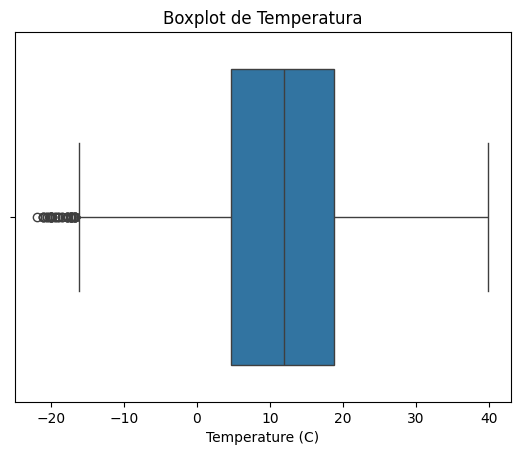

Lìmite inferior: -16.53611111111111
Limite superior: 40.06388888888888
Numeros de valores anomalos detectados:  44


In [ ]:
print("Resumen estadistico: ")
print(df.describe())  #  Para tener una idea general, calculamos estadisticas descriptivas de todas las columnas numericas del df, para identificar posibles valores como el min y max

# Graficar datos (Boxplot)
sns.boxplot(x=df['Temperature (C)'])  # Para observar valores atipicos o outliers en la columna temperatura.
plt.title('Boxplot de Temperatura')
plt.show()

# Definir limites basados en el rango intercuartilico (IQR)
# Q1 es el valor que separa el 25% inferior de los datos, el Q3 es el valor que separa el 25% superior de los datos
Q1  = df['Temperature (C)'].quantile(0.25) # Primer cuartil, 25% de los datos estan por debajo de este valor
Q3  = df['Temperature (C)'].quantile(0.75)  # Tercer cuartil, 75% de los datos estan por debajo de este valor
IQR = Q3 - Q1 # Rango intercuartilico, es la distancia entre Q3 y Q1, representando el rango atipico de los datos.

# Limites superior e inferior
lower_bound = Q1  - 1.5 * IQR
upper_bound = Q3  + 1.5 * IQR

# Identificar valores atipicos
anomalies = (df['Temperature (C)'] < lower_bound) | (df['Temperature (C)'] >  upper_bound)  # Identificamos las filas que estan fuera de los limites calculados

# Mostrar estadisticas de valores atipicos
print(f"Lìmite inferior: {lower_bound}")
print(f"Limite superior: {upper_bound}")
print("Numeros de valores anomalos detectados: ", anomalies.sum())  # Contamos cuantos valores cumplen con la condicion

`Variable Humidity ya que tiene relacion directa con la temperatura`

Limites para 'Humidity' : 0.16 a 1.33 
Numero de valores atipicos en 'Humidity': 46


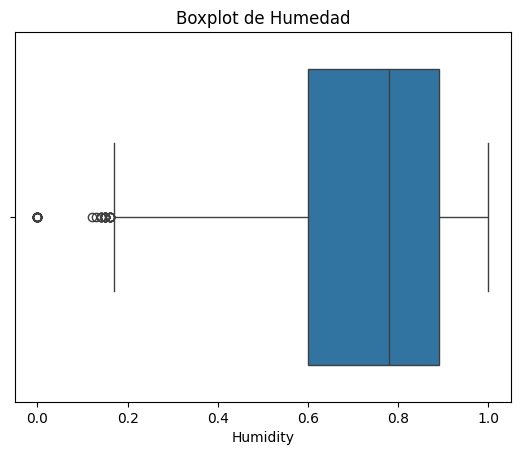

In [ ]:
# Calcular cuartiles e IQR para Humidity
Q1_humidity   = df['Humidity'].quantile(0.25)
Q3_humidity   = df['Humidity'].quantile(0.75)
IQR_humidity  = Q3_humidity - Q1_humidity

# Limites para identificar valores atipicos
lower_bound_humidity  = Q1_humidity - 1.5 * IQR_humidity
upper_bound_humidity    = Q3_humidity + 1.5 * IQR_humidity

# Identificar valores atipicos
anomalies_humidity  = (df['Humidity'] < lower_bound_humidity) | (df['Humidity'] > upper_bound_humidity)

# Mostrar estadisticas
print(f"Limites para 'Humidity' : {lower_bound_humidity:.2f} a {upper_bound_humidity:.2f} ")
print(f"Numero de valores atipicos en 'Humidity': {anomalies_humidity.sum()}")

# Visualizar los datos con un Boxplot
sns.boxplot(x=df['Humidity'])
plt.title('Boxplot de Humedad')
plt.show()

`Variable Wind Speed (km/h) que influye en la percepcion termica`

Límites para 'Wind Speed (km/h)': -6.37 a 26.41
Número de valores atípicos en 'Wind Speed (km/h)': 3069


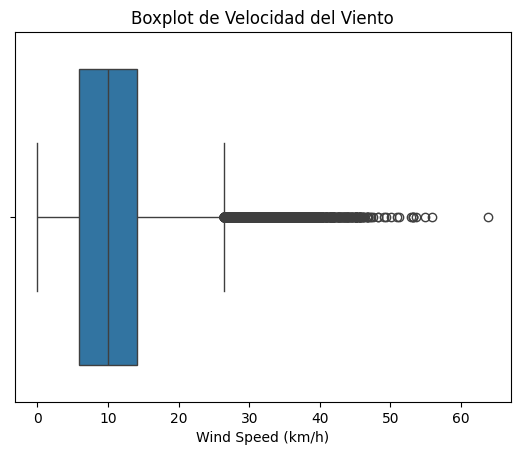

In [ ]:
# Calcular cuartiles e IQR para Wind Speed
Q1_wind_speed = df['Wind Speed (km/h)'].quantile(0.25)
Q3_wind_speed = df['Wind Speed (km/h)'].quantile(0.75)
IQR_wind_speed = Q3_wind_speed - Q1_wind_speed

# Limites para identificar valores atipicos
lower_bound_wind_speed    = Q1_wind_speed - 1.5 * IQR_wind_speed
upper_bound_wind_speed    = Q3_wind_speed + 1.5 * IQR_wind_speed

# Identificar valores atípicos
anomalies_wind_speed = (df['Wind Speed (km/h)'] < lower_bound_wind_speed) | (df['Wind Speed (km/h)'] > upper_bound_wind_speed)

# Mostrar estadísticas
print(f"Límites para 'Wind Speed (km/h)': {lower_bound_wind_speed:.2f} a {upper_bound_wind_speed:.2f}")
print(f"Número de valores atípicos en 'Wind Speed (km/h)': {anomalies_wind_speed.sum()}")

# Visualizar los datos con un boxplot
sns.boxplot(x=df['Wind Speed (km/h)'])
plt.title('Boxplot de Velocidad del Viento')
plt.show()

`Variable Pressure (millibars) que tiene relacion estrecha con patrones climaticos`

Límites para 'Pressure (millibars)': 998.17 a 1034.81
Número de valores atípicos en 'Pressure (millibars)': 4424


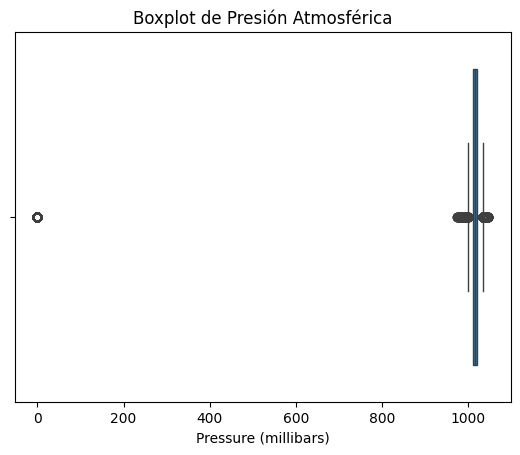

In [ ]:
# Calcular cuartiles e IQR para Pressure
Q1_pressure = df['Pressure (millibars)'].quantile(0.25)
Q3_pressure = df['Pressure (millibars)'].quantile(0.75)
IQR_pressure = Q3_pressure - Q1_pressure

# Límites para identificar valores atípicos
lower_bound_pressure = Q1_pressure - 1.5 * IQR_pressure
upper_bound_pressure = Q3_pressure + 1.5 * IQR_pressure

# Identificar valores atípicos
anomalies_pressure = (df['Pressure (millibars)'] < lower_bound_pressure) | (df['Pressure (millibars)'] > upper_bound_pressure)

# Mostrar estadísticas
print(f"Límites para 'Pressure (millibars)': {lower_bound_pressure:.2f} a {upper_bound_pressure:.2f}")
print(f"Número de valores atípicos en 'Pressure (millibars)': {anomalies_pressure.sum()}")

# Visualizar los datos con un boxplot
sns.boxplot(x=df['Pressure (millibars)'])
plt.title('Boxplot de Presión Atmosférica')
plt.show()

`Decidimos que hacer con los valores atipicos en las tres variables mas temperatura ya que es la variable objetivo`

Valores atípicos restantes en 'Humidity': 0
Valores atípicos restantes en 'Wind Speed (km/h)': 0
Valores atípicos restantes en 'Pressure (millibars)': 0
Valores atípicos restantes en 'Temperature (C)': 0

Resumen estadístico después de tratar los valores atípicos:
       Temperature (C)      Humidity  Wind Speed (km/h)  \
count     93966.000000  93966.000000       93966.000000   
mean         12.017696      0.734014          10.490960   
std           9.555460      0.195421           6.178771   
min         -16.111111      0.170000           0.000000   
25%           4.755556      0.600000           5.860400   
50%          12.105556      0.780000           9.837100   
75%          18.881944      0.890000          14.023100   
max          39.905556      1.000000          26.404000   

       Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
count            93966.000000     93966.000000     93966.0   
mean               187.385097        10.390810         0.0   
std              

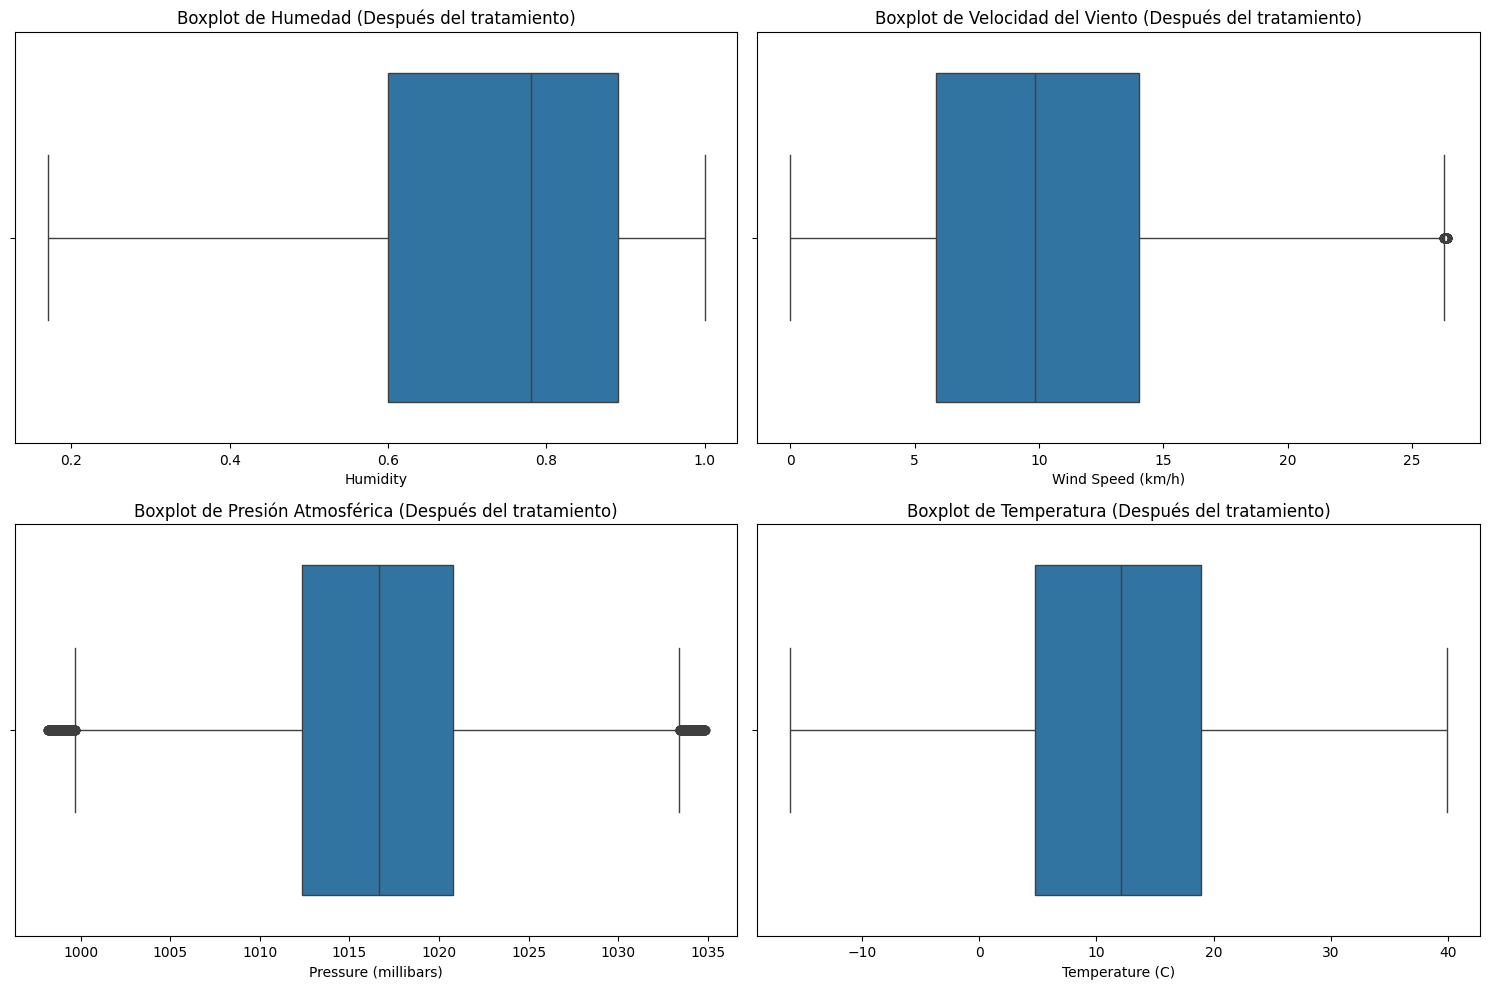

In [ ]:
# Calcular la mediana de Humidity
median_humidity = df['Humidity'].median() # Elegimos imputar con la mediana, ya que este es un valor tipico no que no distorsionara el modelo

# Reemplazar los valores atipicos con la mediana
df.loc[anomalies_humidity, 'Humidity']  = median_humidity

# Calcular el percentil 95 para Wind Speed
percentile_95_wind_speed  = df['Wind Speed (km/h)'].quantile(0.95)  # Imputarmos con el percentil 95 o la mediana, para suavizar su impacto sin eliminarlos, ya que no parecen ser errores pero son raros y podrian sesgar el modelo

# Reemplazar valores atipicos con el percentil 95
df.loc[anomalies_wind_speed, 'Wind Speed (km/h)'] = percentile_95_wind_speed

# Eliminar valores de precision cercanos a 0.0
df  = df[df['Pressure (millibars)'] >= lower_bound_pressure]  # Eliminamos los valores 0.0 y remplazarlos por valores superiores a 1034.81 con la mediana

# Calcular la mediana de Pressure
median_pressure = df['Pressure (millibars)'].median()

# Reemplazar valores superiores al limite con la mediana
df.loc[anomalies_pressure, 'Pressure (millibars)']  = median_pressure

# Calcular la mediana de Temperature
median_temperature  = df['Temperature (C)'].median()  # Reemplazamos valores atipicos fuera del rango con la mediana, ya que representan eventos extremos pero relevantes para el modelo

# Reemplazar los valores atipicos con la mediana
df.loc[anomalies, 'Temperature (C)']  = median_temperature

# Verificar si quedan valores atípicos para cada variable

# Humidity
anomalies_humidity_post = (df['Humidity'] < lower_bound_humidity) | (df['Humidity'] > upper_bound_humidity)
print(f"Valores atípicos restantes en 'Humidity': {anomalies_humidity_post.sum()}")

# Wind Speed
anomalies_wind_speed_post = (df['Wind Speed (km/h)'] < lower_bound_wind_speed) | (df['Wind Speed (km/h)'] > upper_bound_wind_speed)
print(f"Valores atípicos restantes en 'Wind Speed (km/h)': {anomalies_wind_speed_post.sum()}")

# Pressure
anomalies_pressure_post = (df['Pressure (millibars)'] < lower_bound_pressure) | (df['Pressure (millibars)'] > upper_bound_pressure)
print(f"Valores atípicos restantes en 'Pressure (millibars)': {anomalies_pressure_post.sum()}")

# Temperature
anomalies_temperature_post = (df['Temperature (C)'] < lower_bound) | (df['Temperature (C)'] > upper_bound)
print(f"Valores atípicos restantes en 'Temperature (C)': {anomalies_temperature_post.sum()}")

# Mostrar resumen estadístico actualizado
print("\nResumen estadístico después de tratar los valores atípicos:")
print(df.describe())

# Visualizar los boxplots actualizados
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.boxplot(x=df['Humidity'])
plt.title('Boxplot de Humedad (Después del tratamiento)')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['Wind Speed (km/h)'])
plt.title('Boxplot de Velocidad del Viento (Después del tratamiento)')

plt.subplot(2, 2, 3)
sns.boxplot(x=df['Pressure (millibars)'])
plt.title('Boxplot de Presión Atmosférica (Después del tratamiento)')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['Temperature (C)'])
plt.title('Boxplot de Temperatura (Después del tratamiento)')

plt.tight_layout()
plt.show()


*   En **Humidity** confirmamos que todos los valores por debajo del 0.16 han sido reemplazados correctamente con la mediana, porque la distribucion es limpia y dentro de los limites aceptables

*   En **Wind Speed (km/h)** los valores superiores a 26.41 km/h fueron reemplazados con el percentil 95 y los valores extremos han sido suavizados, ya no quedan puntos fuera de los bigotes


*   En **Pressure** los valores cercanos a 0.0 fueron eliminados y los valores superiores a 1034.81 fueron reemplazados con la mediana, ahora la distribucion es clara.








Paso 1.6: Selección de Variables y Atributos Temporales


```
# Las variables que tienen relevancia o relacion directa son
1.   Summary
2.   Precip Type
1.   Fecha
```
Descartamos **Daily Summary** por redundancia.

Incluimos Summary porque puede influir en la temperatura, Precip Type porque se relaciona de manera directa y Fecha porque podemos extraer caracteristicas propias de la variable como "mes", "hora" y nos pueden otorgar insights


In [ ]:
# Convertir la columna Precip Type en variables dummies
df  = pd.get_dummies(df, columns=['Precip Type'], drop_first=True)  # Esto genera una nueva columna Precip Type_snow (1 si es nieve y 0 si es lluvia)

# Conversion de la columna Summary
print(df['Summary'].nunique())  # Vemos la cantidad de categorias unicas
print(df['Summary'].value_counts()) # Ver las categorias mas frecuentes

df  = pd.get_dummies(df, columns=['Summary'], drop_first=True)  # Generamos multiples columnas del tipo Summary_Partly Cloud, Summary_Mostly Cloud, etc

print(df.head())  # Primeras filas del df
print(df.info())  # Estructura del df

27
Summary
Partly Cloudy                          31502
Mostly Cloudy                          27605
Overcast                               15944
Clear                                  10151
Foggy                                   6968
Breezy and Mostly Cloudy                 471
Breezy and Overcast                      453
Breezy and Partly Cloudy                 371
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   60
Light Rain                                57
Windy and Overcast                        41
Humid and Mostly Cloudy                   40
Drizzle                                   37
Dry                                       34
Breezy and Foggy                          30
Breezy                                    30
Windy and Mostly Cloudy                   30
Humid and Partly Cloudy                   17
Dry and Mostly Cloudy                     14
Rain                                      10
Humid and Overcast                         7

**Precip Type** en sus valores 0 (lluvia) y 1 (nieve)

Para **Summary** se ha creado una columna dummie para cada categoria excepto la primera, tenemos columnas como Summary_Partly Cloudy, Summary_Dry, etc. Ahora tenemos 26 columnas binarias o booleanas, lo que permite al modelo capturar mayor precision cada condicion climatica

En cuanto a la variable **Fecha** se ha transformado en caracteristicas utiles. año, month, day, hour para detectar patrones atemporales o variaciones de temperatura a lo largo del año o del dia.


# **Parte 2 - Seleccion de Variables y Atributos Temporales**

Paso 2.1: Eleccion de variables

Seleccionamos variables con base en los siguientes Criterios:


1.   Relevancia para la temperatura:
  *   Factores directamente relacionados
  *   Variables indirectas o redundantes son descartadas

2.   Colinealidad:
  *   Si dos variables estan fuertemente correlacionadas, eliminamos una para evitar redundancias

3.   Informacion temporal:
  *   La hora del dia y el mes pueden influir significativamente en la temperatura, por lo que se consideran



```
# Humidity ya que tiene relacion directa
```
```
# Wind Speed (km/h) influye en la sensacion termica
```

```
# Visibility (km) niebla y visibilidad afecta como se percibe la temperatura
```
```
# Pressure (millibars) se relaciona con cambios climaticos
```
```
# Precip Type_snow  la nieve afecta directamente la temperatura
```
```
# Summary_* contiene la info meteorologica detallada
```
```
# month la temperatura varia con las estaciones del año
```
```
# hour igual que en el mes, la temperatura varia a lo largo del dia
```
Excluimos **Wind Bearing (degrees)** ya que no influte directamente con la temperatura, **year** porque solo hay datos de un año, no aporta info y **day** ya que no es relevante a largo plazo

In [ ]:
selected_features = [
    'Humidity',
    'Wind Speed (km/h)',
    'Visibility (km)',
    'Pressure (millibars)',
    'Precip Type_snow',
    'month',
    'hour'
]

# Añadir las columnas dummy de Summary
summary_features = [col for col in df.columns if 'Summary_' in col]
selected_features.extend(summary_features)

print("Variables seleccionadas para el modelo:")
print(selected_features)

Variables seleccionadas para el modelo:
['Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)', 'Precip Type_snow', 'month', 'hour', 'Summary_Breezy and Dry', 'Summary_Breezy and Foggy', 'Summary_Breezy and Mostly Cloudy', 'Summary_Breezy and Overcast', 'Summary_Breezy and Partly Cloudy', 'Summary_Clear', 'Summary_Dangerously Windy and Partly Cloudy', 'Summary_Drizzle', 'Summary_Dry', 'Summary_Dry and Mostly Cloudy', 'Summary_Dry and Partly Cloudy', 'Summary_Foggy', 'Summary_Humid and Mostly Cloudy', 'Summary_Humid and Overcast', 'Summary_Humid and Partly Cloudy', 'Summary_Light Rain', 'Summary_Mostly Cloudy', 'Summary_Overcast', 'Summary_Partly Cloudy', 'Summary_Rain', 'Summary_Windy', 'Summary_Windy and Dry', 'Summary_Windy and Foggy', 'Summary_Windy and Mostly Cloudy', 'Summary_Windy and Overcast', 'Summary_Windy and Partly Cloudy']


Paso 2.2: Creacion de variables temporales

In [ ]:
# Convertir la columna 'Fecha' a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Extraer características de la fecha
df['year'] = df['Fecha'].dt.year  # Año
df['month'] = df['Fecha'].dt.month  # Mes
df['day'] = df['Fecha'].dt.day  # Día
df['hour'] = df['Fecha'].dt.hour  # Hora

# Eliminar la columna original de fecha
df.drop(columns=['Fecha'], inplace=True)

print(df[['year', 'month', 'day', 'hour']].head())

   year  month  day  hour
0  2006      4    1     0
1  2006      4    1     1
2  2006      4    1     2
3  2006      4    1     3
4  2006      4    1     4


Variables temporales seleccionadas


```
# month ya que la temperatura varia estacionalmente segun el mes del año
```

```
# hour ya que la temperatura varia durante el dia
```
No elegimos **year** ya que es solo un año en el dataset ni **day** porque podria producir ruido y la temperatura usualmente no cambia de un dia a otro significativamente

In [ ]:
# Seleccion de variables temporales relevantes
df_temporal = df[['month', 'hour']]
print(df_temporal.head())

   month  hour
0      4     0
1      4     1
2      4     2
3      4     3
4      4     4


# **Parte 3 - Desarrollo y evaluacion de un modelo de regresion**

Paso 3.1: Preparacion de los datos

In [ ]:
from re import X
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Seleccionar las variables relevantes
selected_features = [
    'Humidity', 'Wind Speed (km/h)', 'Visibility (km)', 'Pressure (millibars)', 'Precip Type_snow', 'month', 'hour'
]

# Añadir las columnas dummy de Summary
summary_features  = [col for col in df.columns if 'Summary_' in col]
selected_features.extend(summary_features)

# Definir X (variables independientes) e y (variable dependiente)
X = df[selected_features]
y = df['Temperature (C)']

# Division del dataset  (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size  = 0.2, random_state = 42)

# Escalar las variables numericas para evitar sesgo de escala
scaler  =  StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de testeo: {X_test.shape}")

Tamaño del conjunto de entrenamiento: (75172, 33)
Tamaño del conjunto de testeo: (18794, 33)


Paso 3.2: Entrenamiento del modelo

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print(f"Decision Tree - MAE: {mae_tree:.2f} °C, R²: {r2_tree:.2f}, RMSE: {rmse_tree:.2f} °C")

Decision Tree - MAE: 2.48 °C, R²: 0.89, RMSE: 3.18 °C



1.   **Error Absoluto Medio o MAE** de 2.48ºC
2.   **RMSE o Error cuadratico medio**: 3.18ºC hay errores significativos en ciertas predicciones pero el modelo aun se desempeña dentro de un margen aceptable
1.   **R2 o Coeficiente de determinacion** 0.89  muestra que el modelo puede explicar el 89% de variabilidad de la temperatura utilizando variables climaticas seleccionadas


Paso 3.3: Prediccion vs valores reales

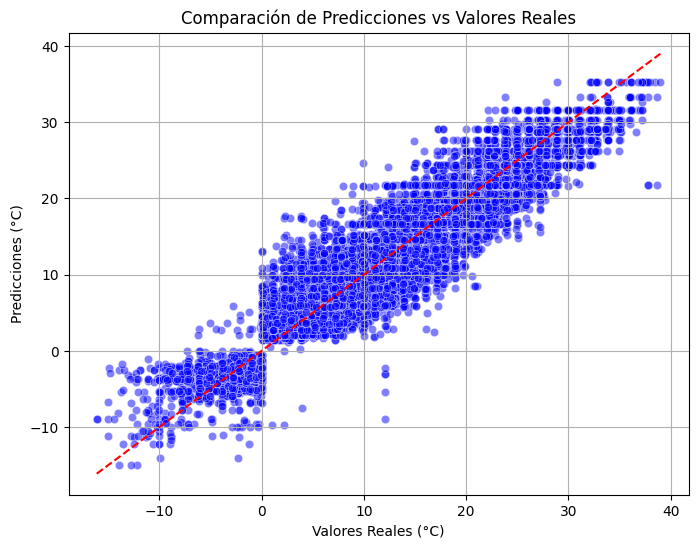

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear gráfico de dispersión entre valores reales y predichos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_tree, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # Línea perfecta
plt.xlabel("Valores Reales (°C)")
plt.ylabel("Predicciones (°C)")
plt.title("Comparación de Predicciones vs Valores Reales")
plt.grid()
plt.show()

La mayoria de las preddiciones estan alineadas pero hay algunas desviaciones para temperaturas extremas.



*   La mayoria de los puntos sigue una tendencia ascendente lo que indica una buena relacion entre las variable sde entrada y la temperatura.
*   El modelo tiene mas dificultades para predecir temperaturas extremas con precision. y con los puntos en la region negativo ( menores a 0ºC)



# **Parte 4 - Reflexion Final**

A lo largo del proceso, se utilizaron diferentes parametros climaticos, se realizaron diversas etapas, desde la exploracion, limpieza con tecnicas de imputacion como nuestro caso el KNN, por la mediana y moda en variable categorica hasta la implementacion del modelo de regresion.
Con el arbol de decision se comprobo una mejor precision, ya que sabemos que existen otros pero quisimos enforcanos en modelo de regresion lineal que no fue muy exacto y luego probar con arbol de decision y con este ultimo se cumplieron los requisitos como el MAE menor a 3ºC y con el coeficiente de determinacion pudimos notar que el modelo si explica la variabilidad y tiene buen desempeño en general. Lo mas complejo fue el analisis, ya que es la parte fuerte de todo el proyecto o la tarea, y saber que hacer con los datos anomalos que quiere de una revision y otra para verificar como quedaron finalmente los valores dentro del dataset. A pesar de los buenos resultados el modelo podria mejorar, ya que hay mayor dispersion con las temperaturas extremas, eso daria paso a otros enfoques, mas prueba y error con otros modelos de regresion para captar estos datos o relaciones no lineales.  Lo que mas valoramos es el analisis del procesamiento de datos, detectar y manejar estos valores que son fundamentales para obtener un modelo "limpio" o mejores resultados. La experiencia es muy grata, toma de varios dias ya que es un compromiso con el codigo, con el entendimiento de saber que hacer o por què razon. Falta mucho por aprender y este es un muy buen comienzo.